# Lab 02 - Parametric Methods
## ENGR421
### October 31, 2025

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as linalg

## Importing Data

In [44]:
# read data into memory0
data_set = np.genfromtxt(fname = "lab02_data_set.csv", delimiter = ",", skip_header = 1)

# get x and y values
x = data_set[:, 0]
y = data_set[:, 1]

# get number of samples
N = data_set.shape[0]

x_test = np.linspace(start = 0, stop = 60, num = 601)

## Plotting Data

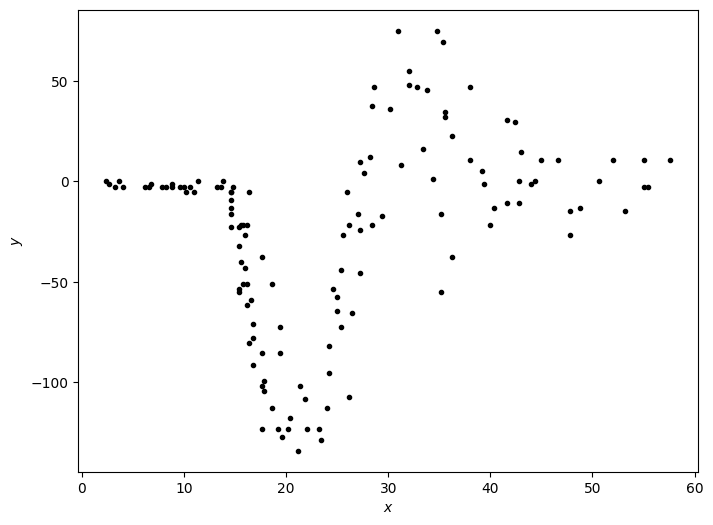

In [45]:
plt.figure(figsize = (8, 6))
plt.plot(x, y, "k.", markersize = 6)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

## Linear Regression

\begin{align*}
    \hat{y}_{i} &= w_{0} + w_{1} x_{i}
\end{align*}

\begin{align*}
\underbrace{\begin{bmatrix} N & \sum\limits_{i = 1}^{N} x_{i}\\ \sum\limits_{i = 1}^{N} x_{i} & \sum\limits_{i = 1}^{N} x_{i}^{2} \end{bmatrix}}_{\mathbf{A}} \underbrace{\begin{bmatrix}w_{0} \\ w_{1} \end{bmatrix}}_{\boldsymbol{w}} &= \underbrace{\begin{bmatrix}\sum\limits_{i = 1}^{N} y_{i} \\ \sum\limits_{i = 1}^{N} y_{i} x_{i} \end{bmatrix}}_{\boldsymbol{b}} \\
\boldsymbol{w} &= \mathbf{A}^{-1} \boldsymbol{b}
\end{align*}

In [46]:
# calculate A
A = np.array([[N, np.sum(x)],
              [np.sum(x), np.sum(x**2)]])
print(A)

[[   133.    3348.8]
 [  3348.8 107082.8]]


In [47]:
# calculate b
b = np.array([[np.sum(y)], [np.sum(y * x)]])
print(b)

[[ -3397.6 ]
 [-60720.36]]


In [48]:
# calculate w
w = np.matmul(linalg.cho_solve(linalg.cho_factor(A), np.eye(2)), b)
print(w)

[[-53.00792021]
 [  1.09067528]]


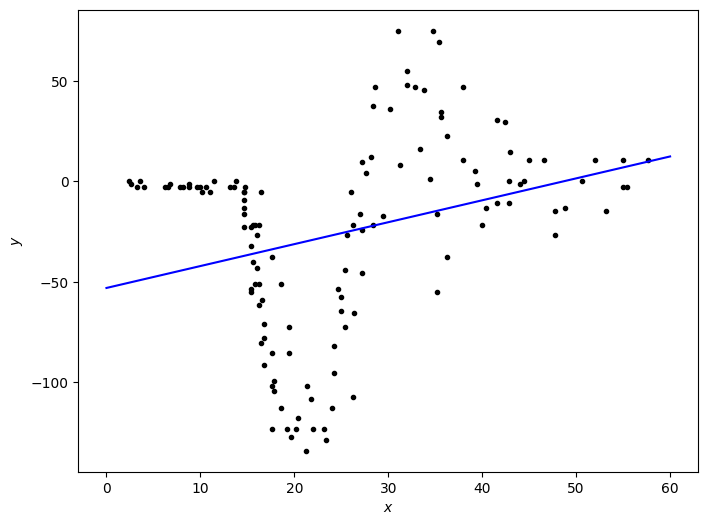

In [49]:
# calculate y_hat for test data
# y_hat_test = w[0] + w[1] * x_test
# alternative way using matrix multiplication

y_hat_test = np.matmul(np.stack((np.repeat(1.0, len(x_test)), x_test)).T, w)


plt.figure(figsize = (8, 6))
plt.plot(x, y, "k.", markersize = 6)
plt.plot(x_test, y_hat_test, "b-")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

## Polynomial Regression

\begin{align*}
    \hat{y}_{i} &= w_{0} + w_{1} \underbrace{x_{i}}_{\normalsize \textrm{$z_{i1}$}} + w_{2} \underbrace{x_{i}^{2}}_{\normalsize \textrm{$z_{i2}$}} + \dots + w_{K} \underbrace{x_{i}^{K}}_{\normalsize \textrm{$z_{iK}$}}
\end{align*}

\begin{align*}
\underbrace{\begin{bmatrix} N & \sum\limits_{i = 1}^{N} x_{i} & \dots &  \sum\limits_{i = 1}^{N} x_{i}^{K}\\ \sum\limits_{i = 1}^{N} x_{i} & \sum\limits_{i = 1}^{N} x_{i}^{2} & \dots & \sum\limits_{i = 1}^{N} x_{i}^{K + 1}\\ \vdots & \vdots & \ddots & \vdots \\
\sum\limits_{i = 1}^{N} x_{i}^{K} & \sum\limits_{i = 1}^{N} x_{i}^{K + 1} & \dots & \sum\limits_{i = 1}^{N} x_{i}^{2K}\end{bmatrix}}_{\mathbf{A}} \underbrace{\begin{bmatrix}w_{0} \\ w_{1} \\ \vdots \\ w_{K} \end{bmatrix}}_{\boldsymbol{w}} &= \underbrace{\begin{bmatrix}\sum\limits_{i = 1}^{N} y_{i} \\ \sum\limits_{i = 1}^{N} y_{i} x_{i} \\ \vdots \\ \sum\limits_{i = 1}^{N} y_{i} x_{i}^{K} \end{bmatrix}}_{\boldsymbol{b}} \\
\boldsymbol{w} &= \mathbf{A}^{-1} \boldsymbol{b}
\end{align*}

In [50]:
def polynomial_regression(x, y, K):
    # calculate A
    A = np.zeros((K + 1, K + 1))
    for i in range(K + 1):
        for j in range(K + 1):
            A[i, j] = np.sum(x**i * x**j)

    # calculate b
    b = np.zeros((K + 1, 1))
    for i in range(K + 1):
        b[i] = np.sum(y * x**i)
        
    # calculate w
    w = np.matmul(linalg.cho_solve(linalg.cho_factor(A), np.eye(K + 1)), b)
    
    return(w)

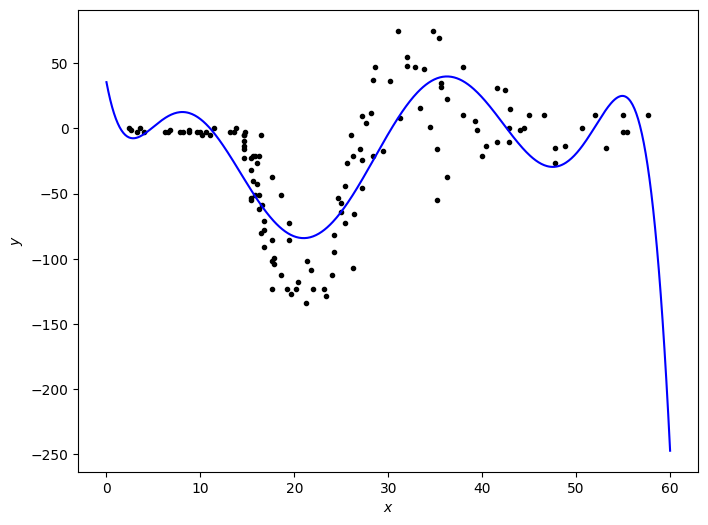

In [51]:
K = 7
w = polynomial_regression(x, y, K)
y_hat_test = np.matmul(np.stack([x_test**k for k in range(K + 1)]).T, w)

plt.figure(figsize = (8, 6))
plt.plot(x, y, "k.", markersize = 6)
plt.plot(x_test, y_hat_test, "b-")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

\begin{align*}
\begin{bmatrix} N & \sum\limits_{i = 1}^{N} x_{i} & \dots &  \sum\limits_{i = 1}^{N} x_{i}^{K}\\ \sum\limits_{i = 1}^{N} x_{i} & \sum\limits_{i = 1}^{N} x_{i}^{2} & \dots & \sum\limits_{i = 1}^{N} x_{i}^{K + 1}\\ \vdots & \vdots & \ddots & \vdots \\
\sum\limits_{i = 1}^{N} x_{i}^{K} & \sum\limits_{i = 1}^{N} x_{i}^{K + 1} & \dots & \sum\limits_{i = 1}^{N} x_{i}^{2K}\end{bmatrix} \begin{bmatrix}w_{0} \\ w_{1} \\ \vdots \\ w_{K} \end{bmatrix} &= \begin{bmatrix}\sum\limits_{i = 1}^{N} y_{i} \\ \sum\limits_{i = 1}^{N} y_{i} x_{i} \\ \vdots \\ \sum\limits_{i = 1}^{N} y_{i} x_{i}^{K} \end{bmatrix} \\
\\
\underbrace{\begin{bmatrix}1 & 1 & \dots & 1\\ x_{1} & x_{2} & \dots & x_{N} \\ \vdots & \vdots & \ddots & \vdots \\ x_{1}^{K} & x_{2}^{K} & \dots & x_{N}^{K} \end{bmatrix}}_{\mathbf{D}^{\top}} \underbrace{\begin{bmatrix}1 & x_{1} & \dots & x_{1}^{K}\\ 1 & x_{2} & \dots & x_{2}^{K} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{N} & \dots & x_{N}^{K} \end{bmatrix}}_{\mathbf{D}} \underbrace{\begin{bmatrix}w_{0} \\ w_{1} \\ \vdots \\ w_{K} \end{bmatrix}}_{\boldsymbol{w}} &= \underbrace{\begin{bmatrix}1 & 1 & \dots & 1\\ x_{1} & x_{2} & \dots & x_{N} \\ \vdots & \vdots & \ddots & \vdots \\ x_{1}^{K} & x_{2}^{K} & \dots & x_{N}^{K} \end{bmatrix}}_{\mathbf{D}^{\top}} \underbrace{\begin{bmatrix}y_{1} \\ y_{2} \\ \vdots \\ y_{N} \end{bmatrix}}_{\boldsymbol{y}} \\
\boldsymbol{w} &= \left(\mathbf{D}^{\top}\mathbf{D}\right)^{-1} \mathbf{D}^{\top} \boldsymbol{y}
\end{align*}

In [52]:
def polynomial_regression(x, y, K):
    # calculate D
    D = np.stack([x**k for k in range(K + 1)]).T

    # calculate w
    w = np.matmul(linalg.cho_solve(linalg.cho_factor(np.matmul(D.T, D)), np.eye(K + 1)),
                  np.matmul(D.T, y[:, None]))

    return(w)

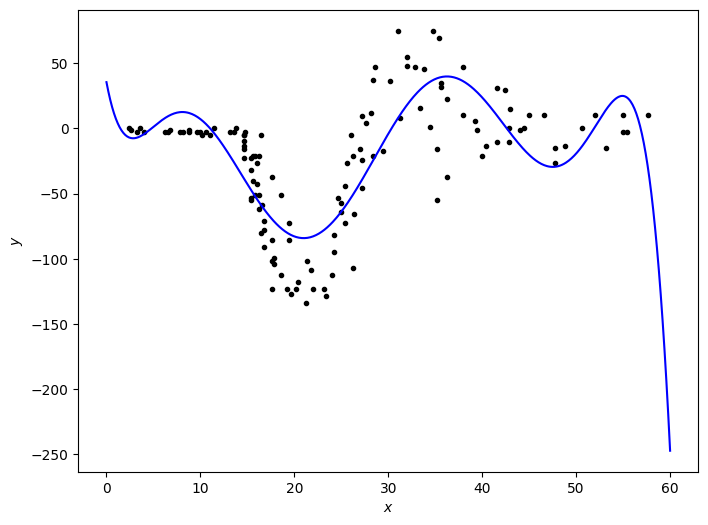

In [53]:
K = 7
w = polynomial_regression(x, y, K)
y_hat_test = np.matmul(np.stack([x_test**k for k in range(K + 1)]).T, w)

plt.figure(figsize = (8, 6))
plt.plot(x, y, "k.", markersize = 6)
plt.plot(x_test, y_hat_test, "b-")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

## Nonlinear Regression

\begin{align*}
    \hat{y}_{i} &= w_{0} + w_{1} \underbrace{\exp\left(-\dfrac{(x_{i} - \mu_{1})^{2}}{2 \sigma^{2}}\right)}_{\normalsize \textrm{$z_{i1}$}} + w_{2} \underbrace{\exp\left(-\dfrac{(x_{i} - \mu_{2})^{2}}{2 \sigma^{2}}\right)}_{\normalsize \textrm{$z_{i2}$}} + \dots + w_{K} \underbrace{\exp\left(-\dfrac{(x_{i} - \mu_{K})^{2}}{2 \sigma^{2}}\right)}_{\normalsize \textrm{$z_{iK}$}}
\end{align*}

In [54]:
def nonlinear_regression(x, y, centers, sigma):
    # calculate D
    D = np.vstack((np.ones((1, len(x))), [np.exp(-(x - centers[k])**2 / (2 * sigma**2))
                                          for k in range(len(centers))])).T

    # calculate w
    w = np.matmul(linalg.cho_solve(linalg.cho_factor(np.matmul(D.T, D)), np.eye(len(centers) + 1)),
                  np.matmul(D.T, y[:, None]))

    return(w)

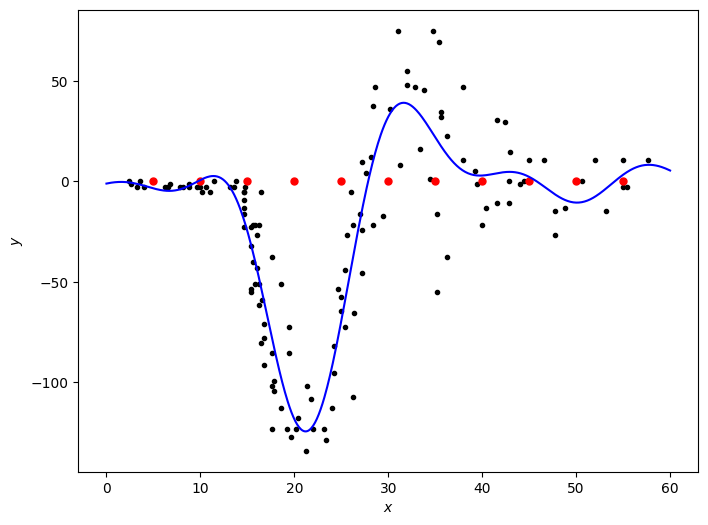

In [55]:
centers = np.linspace(start = 5, stop = 55, num = 11)
sigma = 5
w = nonlinear_regression(x, y, centers, sigma)
D_test = np.vstack((np.ones((1, len(x_test))), [np.exp(-(x_test - centers[k])**2 / (2 * sigma**2))
                                                for k in range(len(centers))])).T
y_hat_test = np.matmul(D_test, w)

plt.figure(figsize = (8, 6))
plt.plot(x, y, "k.", markersize = 6)
plt.plot(centers, np.repeat(0, len(centers)), "r.", markersize = 10)
plt.plot(x_test, y_hat_test, "b-")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
linear_model = LinearRegression()
linear_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
linear_model.fit(x[:, None], y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
print(linear_model.coef_) # w1
print(linear_model.intercept_) # w0

[1.09067528]
-53.00792020755944


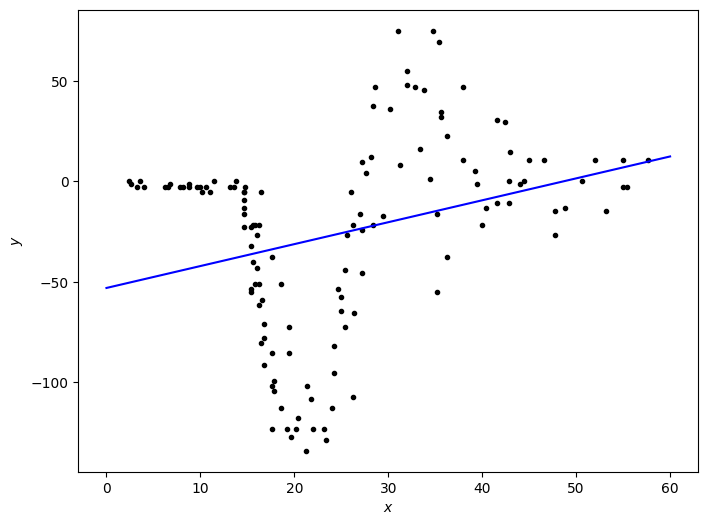

In [60]:
y_hat_test = linear_model.predict(x_test[:, None])

plt.figure(figsize = (8, 6))
plt.plot(x, y, "k.", markersize = 6)
plt.plot(x_test, y_hat_test, "b-")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()